In [19]:
import mynn
from draw_tools.plot import plot
import numpy as np
from struct import unpack
import pickle
import gzip
import matplotlib.pyplot as plt

# fixed seed for experiment
np.random.seed(309)

train_images_path = r'.\dataset\MNIST\train-images-idx3-ubyte.gz'
train_labels_path = r'.\dataset\MNIST\train-labels-idx1-ubyte.gz'

with gzip.open(train_images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        train_imgs=np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(train_labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        train_labs = np.frombuffer(f.read(), dtype=np.uint8)


# choose 10000 samples from train set as validation set.
idx = np.random.permutation(np.arange(num))
# save the index.
with open('idx.pickle', 'wb') as f:
        pickle.dump(idx, f)
train_imgs = train_imgs[idx]
train_labs = train_labs[idx]
valid_imgs = train_imgs[:10000]
valid_labs = train_labs[:10000]
train_imgs = train_imgs[10000:]
train_labs = train_labs[10000:]

# normalize from [0, 255] to [0, 1]
train_imgs = train_imgs / train_imgs.max()
valid_imgs = valid_imgs / valid_imgs.max()



In [20]:
def train_model(nHidden = [128], lr=0.06, epochs=3,early_stop=3, initialize_method='He'):
    # 模型结构：输入层 + 隐藏层 + 输出层
    size_list = [train_imgs.shape[1]] + nHidden + [10]
    lambda_list = [1e-4] * (len(nHidden) + 1)  # 每层一个lambda
    
    # 初始化组件
    model = mynn.models.Model_MLP(size_list, 'ReLU', lambda_list, dropout_p=None, initialize_method=initialize_method)
    my_optimizer = mynn.optimizer.MomentGD(init_lr=lr, model=model, mu=0.9)

    # scheduler = mynn.lr_scheduler.StepLR(my_optimizer, step_size= 100, gamma=0.5)
    # scheduler = mynn.lr_scheduler.MultiStepLR(my_optimizer, milestones=[500, 1500, 2500, 3000], gamma=0.5)
    scheduler = mynn.lr_scheduler.ExponentialLR(my_optimizer, gamma=0.95)
    loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    
    
    # 训练运行器
    trainer = mynn.runner.RunnerM(
        model=model,
        optimizer=my_optimizer,
        metric=mynn.metric.accuracy,
        loss_fn=loss_fn,
        batch_size=32,
        scheduler=scheduler
    )
    
    # 执行训练
    trainer.train(
        train_set=[train_imgs, train_labs],
        dev_set=[valid_imgs, valid_labs],
        num_epochs=epochs,
        log_iters=200,
        early_stop = early_stop,
        # save_dir = f'./saved_models/Q2/{lr}_StepLR'
        # save_dir = f'./saved_models/Q2/{lr}_MultiStepLR'
        save_dir = f'./saved_models/Q2/{lr}_ExponentialLR'
    )
    
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 绘制训练和验证损失曲线
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Iters')  # x轴标签
    axes[0].set_ylabel('Loss')    # y轴标签
    axes[0].legend()

    # 绘制训练和验证准确度曲线
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Iters')  # x轴标签
    axes[1].set_ylabel('Accuracy')  # y轴标签
    axes[1].legend()

    plt.tight_layout()  # 自动调整布局
    plt.show()
    
    return trainer

#### StepLR

[Iter 200]
[Train] loss: 0.30440, score: 0.90625
[Dev] loss: 0.33230, score: 0.90740
[Iter 400]
[Train] loss: 0.11083, score: 0.96875
[Dev] loss: 0.29813, score: 0.91620
[Iter 600]
[Train] loss: 0.41169, score: 0.90625
[Dev] loss: 0.29173, score: 0.91900
[Iter 800]
[Train] loss: 0.35111, score: 0.93750
[Dev] loss: 0.28959, score: 0.91970
[Iter 1000]
[Train] loss: 0.37982, score: 0.87500
[Dev] loss: 0.28904, score: 0.91990
[Iter 1200]
[Train] loss: 0.13779, score: 1.00000
[Dev] loss: 0.28888, score: 0.91980
[Iter 1400]
[Train] loss: 0.23823, score: 0.90625
[Dev] loss: 0.28883, score: 0.91980
best accuracy updated: 0.00000 --> 0.91980
[Iter 1600]
[Train] loss: 0.25627, score: 0.87500
[Dev] loss: 0.28882, score: 0.91980
[Iter 1800]
[Train] loss: 0.67584, score: 0.81250
[Dev] loss: 0.28882, score: 0.91980
[Iter 2000]
[Train] loss: 0.12727, score: 0.96875
[Dev] loss: 0.28881, score: 0.91980
[Iter 2200]
[Train] loss: 0.32637, score: 0.90625
[Dev] loss: 0.28881, score: 0.91980
[Iter 2400]
[Tr

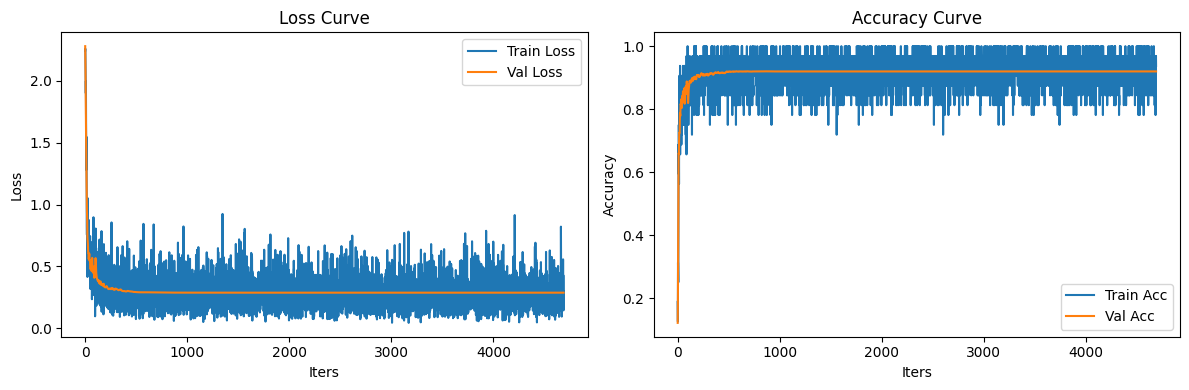

Best train set accuracy: 1.0
Best validation set accuracy: 0.9198


In [4]:
trainer_1 = train_model(lr = 1)
print("Best train set accuracy:", max(trainer_1.train_scores))
print("Best validation set accuracy:", trainer_1.best_score)

[Iter 200]
[Train] loss: 0.82283, score: 0.81250
[Dev] loss: 0.66967, score: 0.85150
[Iter 400]
[Train] loss: 0.59629, score: 0.84375
[Dev] loss: 0.58856, score: 0.86490
[Iter 600]
[Train] loss: 1.05942, score: 0.68750
[Dev] loss: 0.57373, score: 0.86730
[Iter 800]
[Train] loss: 0.56364, score: 0.84375
[Dev] loss: 0.57036, score: 0.86640
[Iter 1000]
[Train] loss: 0.78918, score: 0.87500
[Dev] loss: 0.56954, score: 0.86730
[Iter 1200]
[Train] loss: 0.56290, score: 0.93750
[Dev] loss: 0.56930, score: 0.86730
[Iter 1400]
[Train] loss: 0.39131, score: 0.90625
[Dev] loss: 0.56925, score: 0.86720
best accuracy updated: 0.00000 --> 0.86720
[Iter 1600]
[Train] loss: 0.71746, score: 0.75000
[Dev] loss: 0.56923, score: 0.86720
[Iter 1800]
[Train] loss: 0.53021, score: 0.84375
[Dev] loss: 0.56923, score: 0.86720
[Iter 2000]
[Train] loss: 0.60193, score: 0.81250
[Dev] loss: 0.56923, score: 0.86720
[Iter 2200]
[Train] loss: 0.46069, score: 0.90625
[Dev] loss: 0.56923, score: 0.86720
[Iter 2400]
[Tr

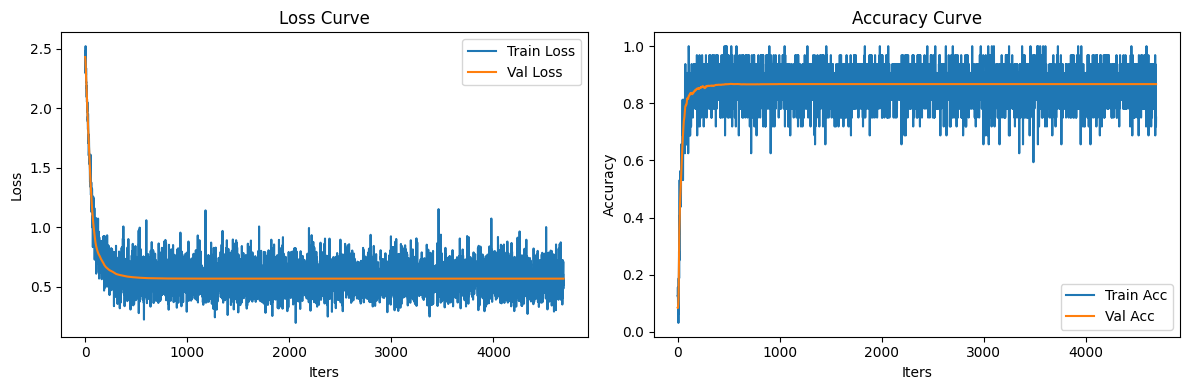

Best train set accuracy: 1.0
Best validation set accuracy: 0.8672


In [5]:
trainer_2 = train_model(lr = 0.1)
print("Best train set accuracy:", max(trainer_2.train_scores))
print("Best validation set accuracy:", trainer_2.best_score)

[Iter 200]
[Train] loss: 1.86782, score: 0.59375
[Dev] loss: 1.93110, score: 0.43570
[Iter 400]
[Train] loss: 1.84614, score: 0.43750
[Dev] loss: 1.83647, score: 0.49370
[Iter 600]
[Train] loss: 1.87184, score: 0.56250
[Dev] loss: 1.81362, score: 0.50820
[Iter 800]
[Train] loss: 1.76988, score: 0.62500
[Dev] loss: 1.80798, score: 0.51070
[Iter 1000]
[Train] loss: 1.78363, score: 0.56250
[Dev] loss: 1.80659, score: 0.51130
[Iter 1200]
[Train] loss: 1.84506, score: 0.46875
[Dev] loss: 1.80624, score: 0.51130
[Iter 1400]
[Train] loss: 1.76465, score: 0.53125
[Dev] loss: 1.80615, score: 0.51130
best accuracy updated: 0.00000 --> 0.51130
[Iter 1600]
[Train] loss: 1.78434, score: 0.62500
[Dev] loss: 1.80613, score: 0.51130
[Iter 1800]
[Train] loss: 1.91755, score: 0.40625
[Dev] loss: 1.80612, score: 0.51130
[Iter 2000]
[Train] loss: 1.83791, score: 0.46875
[Dev] loss: 1.80612, score: 0.51130
[Iter 2200]
[Train] loss: 1.79398, score: 0.56250
[Dev] loss: 1.80612, score: 0.51130
[Iter 2400]
[Tr

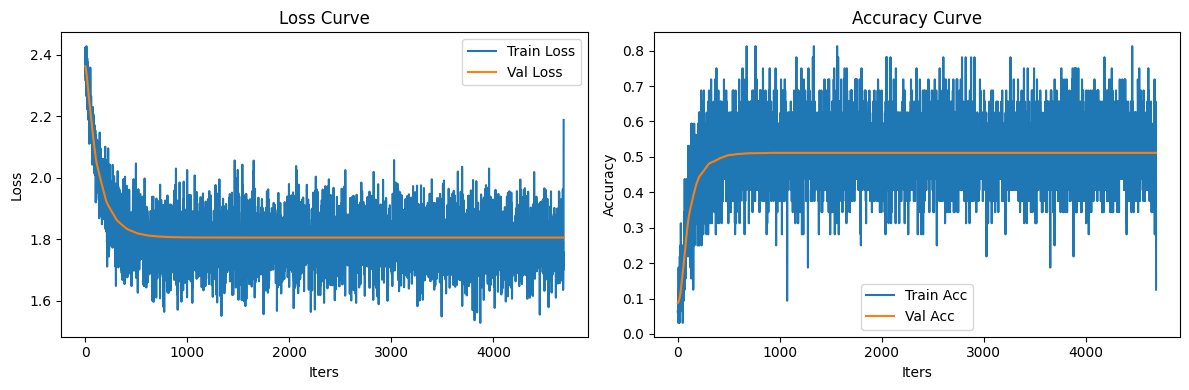

Best train set accuracy: 0.8125
Best validation set accuracy: 0.5113


In [6]:
trainer_3 = train_model(lr = 0.01)
print("Best train set accuracy:", max(trainer_3.train_scores))
print("Best validation set accuracy:", trainer_3.best_score)

[Iter 200]
[Train] loss: 2.39181, score: 0.06250
[Dev] loss: 2.33302, score: 0.10570
[Iter 400]
[Train] loss: 2.32548, score: 0.09375
[Dev] loss: 2.31774, score: 0.11140
[Iter 600]
[Train] loss: 2.23975, score: 0.15625
[Dev] loss: 2.31399, score: 0.11330
[Iter 800]
[Train] loss: 2.32899, score: 0.09375
[Dev] loss: 2.31307, score: 0.11360
[Iter 1000]
[Train] loss: 2.26809, score: 0.15625
[Dev] loss: 2.31284, score: 0.11360
[Iter 1200]
[Train] loss: 2.36025, score: 0.09375
[Dev] loss: 2.31278, score: 0.11360
[Iter 1400]
[Train] loss: 2.27558, score: 0.09375
[Dev] loss: 2.31277, score: 0.11360
best accuracy updated: 0.00000 --> 0.11360
[Iter 1600]
[Train] loss: 2.25373, score: 0.06250
[Dev] loss: 2.31276, score: 0.11360
[Iter 1800]
[Train] loss: 2.26767, score: 0.15625
[Dev] loss: 2.31276, score: 0.11360
[Iter 2000]
[Train] loss: 2.30331, score: 0.09375
[Dev] loss: 2.31276, score: 0.11360
[Iter 2200]
[Train] loss: 2.35313, score: 0.06250
[Dev] loss: 2.31276, score: 0.11360
[Iter 2400]
[Tr

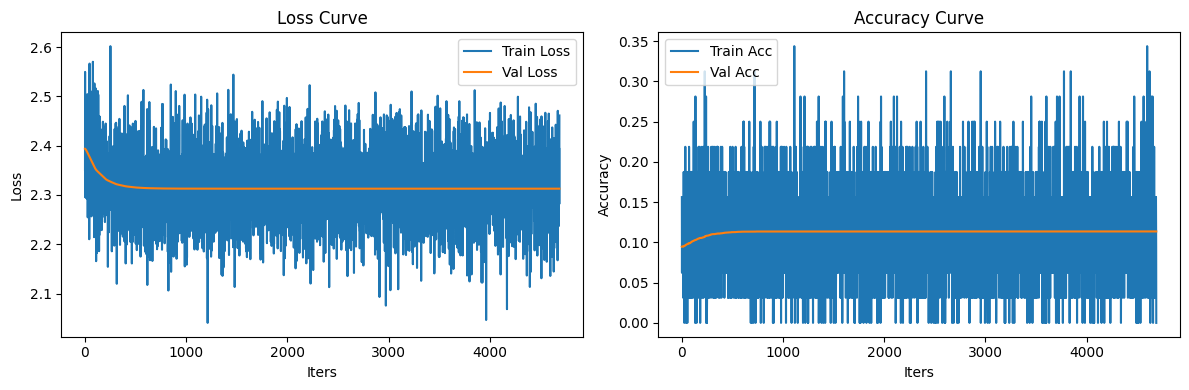

Best train set accuracy: 0.34375
Best validation set accuracy: 0.1136


In [7]:
trainer_3_5 = train_model(lr = 0.001)
print("Best train set accuracy:", max(trainer_3_5.train_scores))
print("Best validation set accuracy:", trainer_3_5.best_score)

##### 可以发现使用StepLR当lr=0.001时训练效果非常差

#### MultiStepLR

[Iter 200]
[Train] loss: 0.27723, score: 0.90625
[Dev] loss: 0.32524, score: 0.90850
[Iter 400]
[Train] loss: 0.14779, score: 0.96875
[Dev] loss: 0.30383, score: 0.90920
[Iter 600]
[Train] loss: 0.33818, score: 0.87500
[Dev] loss: 0.24747, score: 0.93250
[Iter 800]
[Train] loss: 0.29621, score: 0.93750
[Dev] loss: 0.22306, score: 0.93800
[Iter 1000]
[Train] loss: 0.31252, score: 0.84375
[Dev] loss: 0.22005, score: 0.93920
[Iter 1200]
[Train] loss: 0.11327, score: 0.96875
[Dev] loss: 0.21857, score: 0.93880
[Iter 1400]
[Train] loss: 0.15021, score: 0.96875
[Dev] loss: 0.20982, score: 0.94580
best accuracy updated: 0.00000 --> 0.94540
[Iter 1600]
[Train] loss: 0.13039, score: 0.96875
[Dev] loss: 0.19899, score: 0.94420
[Iter 1800]
[Train] loss: 0.43326, score: 0.87500
[Dev] loss: 0.19044, score: 0.94680
[Iter 2000]
[Train] loss: 0.06391, score: 1.00000
[Dev] loss: 0.18829, score: 0.94920
[Iter 2200]
[Train] loss: 0.19558, score: 0.93750
[Dev] loss: 0.18811, score: 0.94960
[Iter 2400]
[Tr

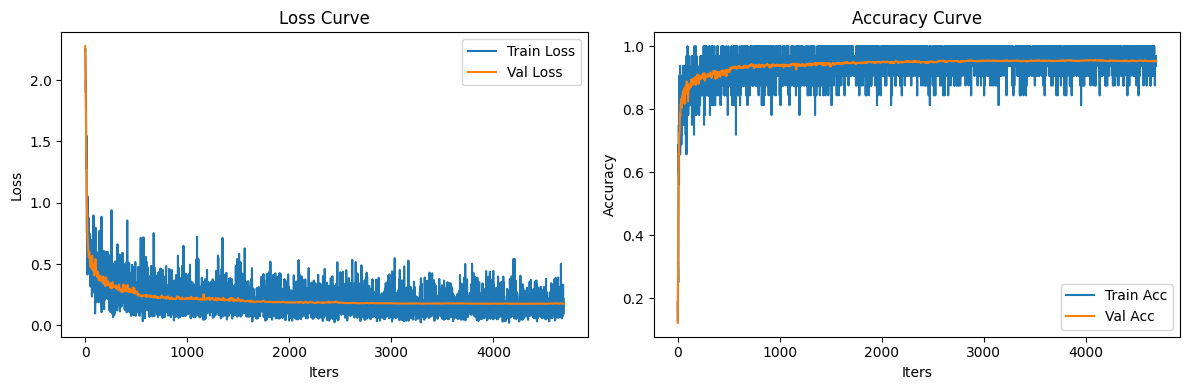

Best train set accuracy: 1.0
Best validation set accuracy: 0.9538


In [12]:
trainer_4 = train_model(lr = 1)
print("Best train set accuracy:", max(trainer_4.train_scores))
print("Best validation set accuracy:", trainer_4.best_score)

[Iter 200]
[Train] loss: 0.75231, score: 0.81250
[Dev] loss: 0.58484, score: 0.86060
[Iter 400]
[Train] loss: 0.42475, score: 0.90625
[Dev] loss: 0.44513, score: 0.88530
[Iter 600]
[Train] loss: 0.98575, score: 0.78125
[Dev] loss: 0.39553, score: 0.89420
[Iter 800]
[Train] loss: 0.36971, score: 0.84375
[Dev] loss: 0.37899, score: 0.89630
[Iter 1000]
[Train] loss: 0.58329, score: 0.90625
[Dev] loss: 0.36614, score: 0.90270
[Iter 1200]
[Train] loss: 0.36378, score: 0.93750
[Dev] loss: 0.35226, score: 0.90700
[Iter 1400]
[Train] loss: 0.20439, score: 0.90625
[Dev] loss: 0.34597, score: 0.90450
best accuracy updated: 0.00000 --> 0.90900
[Iter 1600]
[Train] loss: 0.50008, score: 0.84375
[Dev] loss: 0.33695, score: 0.90850
[Iter 1800]
[Train] loss: 0.31491, score: 0.87500
[Dev] loss: 0.33310, score: 0.90920
[Iter 2000]
[Train] loss: 0.41185, score: 0.84375
[Dev] loss: 0.32967, score: 0.91090
[Iter 2200]
[Train] loss: 0.17580, score: 1.00000
[Dev] loss: 0.32485, score: 0.91060
[Iter 2400]
[Tr

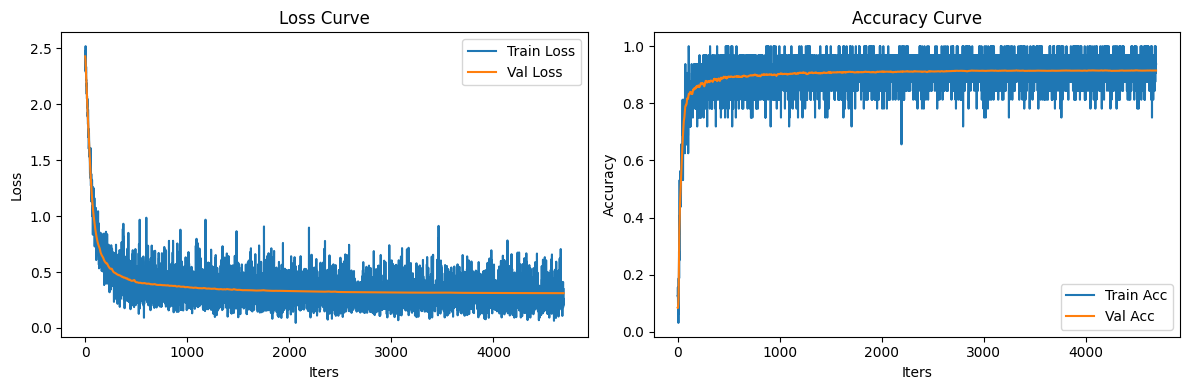

Best train set accuracy: 1.0
Best validation set accuracy: 0.9147


In [13]:
trainer_5 = train_model(lr = 0.1)
print("Best train set accuracy:", max(trainer_5.train_scores))
print("Best validation set accuracy:", trainer_5.best_score)

[Iter 200]
[Train] loss: 1.74258, score: 0.62500
[Dev] loss: 1.82393, score: 0.50290
[Iter 400]
[Train] loss: 1.41612, score: 0.78125
[Dev] loss: 1.45020, score: 0.64990
[Iter 600]
[Train] loss: 1.28334, score: 0.78125
[Dev] loss: 1.23498, score: 0.71750
[Iter 800]
[Train] loss: 1.14285, score: 0.75000
[Dev] loss: 1.12471, score: 0.74740
[Iter 1000]
[Train] loss: 1.01767, score: 0.84375
[Dev] loss: 1.03539, score: 0.76650
[Iter 1200]
[Train] loss: 1.03165, score: 0.68750
[Dev] loss: 0.96069, score: 0.78500
[Iter 1400]
[Train] loss: 0.83545, score: 0.81250
[Dev] loss: 0.89722, score: 0.79900
best accuracy updated: 0.00000 --> 0.80680
[Iter 1600]
[Train] loss: 1.00557, score: 0.84375
[Dev] loss: 0.85595, score: 0.80790
[Iter 1800]
[Train] loss: 1.05812, score: 0.78125
[Dev] loss: 0.83240, score: 0.81050
[Iter 2000]
[Train] loss: 0.88366, score: 0.81250
[Dev] loss: 0.81116, score: 0.81220
[Iter 2200]
[Train] loss: 0.75634, score: 0.81250
[Dev] loss: 0.79022, score: 0.81790
[Iter 2400]
[Tr

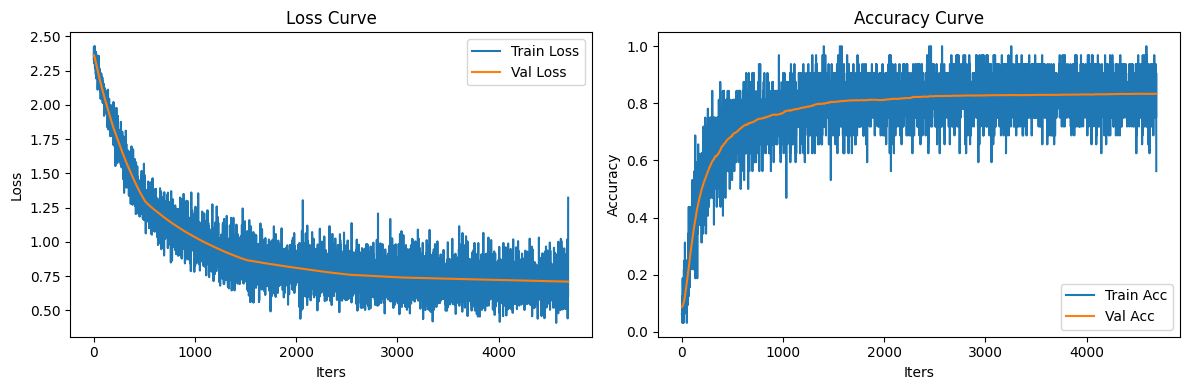

Best train set accuracy: 1.0
Best validation set accuracy: 0.8334


In [14]:
trainer_6 = train_model(lr = 0.01)
print("Best train set accuracy:", max(trainer_6.train_scores))
print("Best validation set accuracy:", trainer_6.best_score)

[Iter 200]
[Train] loss: 2.37061, score: 0.06250
[Dev] loss: 2.31578, score: 0.11180
[Iter 400]
[Train] loss: 2.23820, score: 0.09375
[Dev] loss: 2.24860, score: 0.14800
[Iter 600]
[Train] loss: 2.12599, score: 0.25000
[Dev] loss: 2.20169, score: 0.18200
[Iter 800]
[Train] loss: 2.20928, score: 0.12500
[Dev] loss: 2.17366, score: 0.20450
[Iter 1000]
[Train] loss: 2.09001, score: 0.31250
[Dev] loss: 2.14652, score: 0.23120
[Iter 1200]
[Train] loss: 2.15357, score: 0.25000
[Dev] loss: 2.12018, score: 0.25800
[Iter 1400]
[Train] loss: 2.07248, score: 0.25000
[Dev] loss: 2.09474, score: 0.28680
best accuracy updated: 0.00000 --> 0.30980
[Iter 1600]
[Train] loss: 2.04656, score: 0.31250
[Dev] loss: 2.07531, score: 0.31240
[Iter 1800]
[Train] loss: 2.10141, score: 0.28125
[Dev] loss: 2.06294, score: 0.32710
[Iter 2000]
[Train] loss: 2.09492, score: 0.31250
[Dev] loss: 2.05040, score: 0.34360
[Iter 2200]
[Train] loss: 2.06472, score: 0.31250
[Dev] loss: 2.03842, score: 0.35860
[Iter 2400]
[Tr

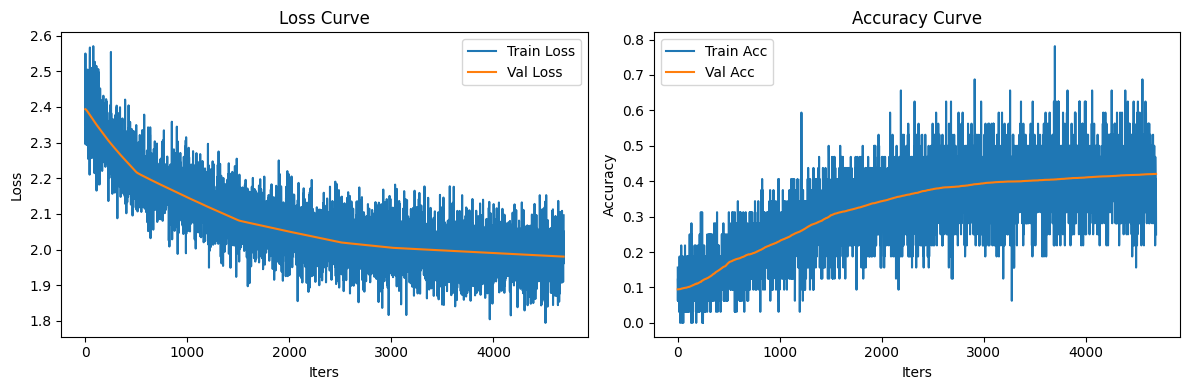

Best train set accuracy: 0.78125
Best validation set accuracy: 0.4207


In [15]:
trainer_6_5 = train_model(lr = 0.001)
print("Best train set accuracy:", max(trainer_6_5.train_scores))
print("Best validation set accuracy:", trainer_6_5.best_score)

#### ExponentialLR

[Iter 200]
[Train] loss: 0.48249, score: 0.84375
[Dev] loss: 0.59184, score: 0.83980
[Iter 400]
[Train] loss: 0.45162, score: 0.87500
[Dev] loss: 0.59182, score: 0.83980
[Iter 600]
[Train] loss: 0.67196, score: 0.84375
[Dev] loss: 0.59182, score: 0.83980
[Iter 800]
[Train] loss: 0.57667, score: 0.90625
[Dev] loss: 0.59182, score: 0.83980
[Iter 1000]
[Train] loss: 0.75989, score: 0.75000
[Dev] loss: 0.59182, score: 0.83980
[Iter 1200]
[Train] loss: 0.39470, score: 0.90625
[Dev] loss: 0.59182, score: 0.83980
[Iter 1400]
[Train] loss: 0.61929, score: 0.75000
[Dev] loss: 0.59182, score: 0.83980
best accuracy updated: 0.00000 --> 0.83980
[Iter 1600]
[Train] loss: 0.61263, score: 0.84375
[Dev] loss: 0.59182, score: 0.83980
[Iter 1800]
[Train] loss: 1.10684, score: 0.71875
[Dev] loss: 0.59182, score: 0.83980
[Iter 2000]
[Train] loss: 0.54111, score: 0.81250
[Dev] loss: 0.59182, score: 0.83980
[Iter 2200]
[Train] loss: 0.49115, score: 0.84375
[Dev] loss: 0.59182, score: 0.83980
[Iter 2400]
[Tr

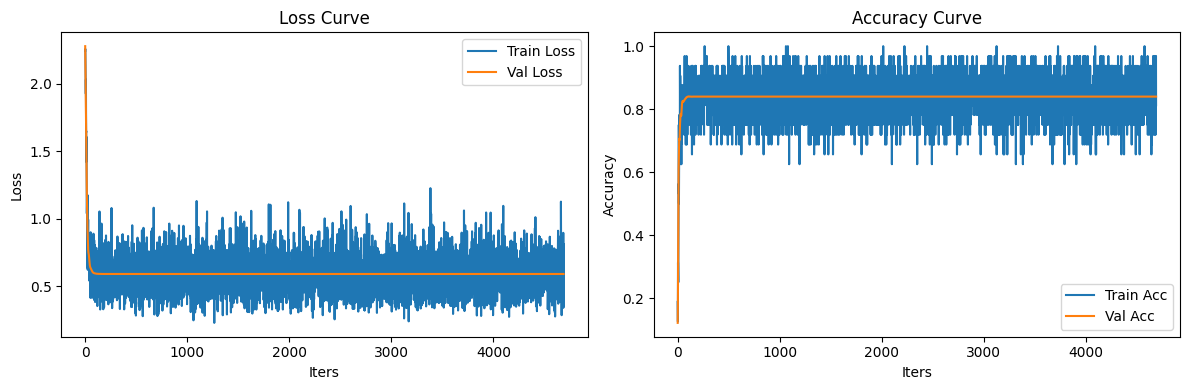

Best train set accuracy: 1.0
Best validation set accuracy: 0.8398


In [21]:
trainer_7 = train_model(lr = 1)
print("Best train set accuracy:", max(trainer_7.train_scores))
print("Best validation set accuracy:", trainer_7.best_score)

[Iter 200]
[Train] loss: 1.86636, score: 0.43750
[Dev] loss: 1.84162, score: 0.50620
[Iter 400]
[Train] loss: 1.87322, score: 0.37500
[Dev] loss: 1.84159, score: 0.50620
[Iter 600]
[Train] loss: 1.94384, score: 0.37500
[Dev] loss: 1.84159, score: 0.50620
[Iter 800]
[Train] loss: 1.82036, score: 0.46875
[Dev] loss: 1.84159, score: 0.50620
[Iter 1000]
[Train] loss: 1.86067, score: 0.46875
[Dev] loss: 1.84159, score: 0.50620
[Iter 1200]
[Train] loss: 1.81501, score: 0.59375
[Dev] loss: 1.84159, score: 0.50620
[Iter 1400]
[Train] loss: 1.81841, score: 0.43750
[Dev] loss: 1.84159, score: 0.50620
best accuracy updated: 0.00000 --> 0.50620
[Iter 1600]
[Train] loss: 1.83118, score: 0.59375
[Dev] loss: 1.84159, score: 0.50620
[Iter 1800]
[Train] loss: 1.80276, score: 0.59375
[Dev] loss: 1.84159, score: 0.50620
[Iter 2000]
[Train] loss: 1.80284, score: 0.59375
[Dev] loss: 1.84159, score: 0.50620
[Iter 2200]
[Train] loss: 1.86879, score: 0.53125
[Dev] loss: 1.84159, score: 0.50620
[Iter 2400]
[Tr

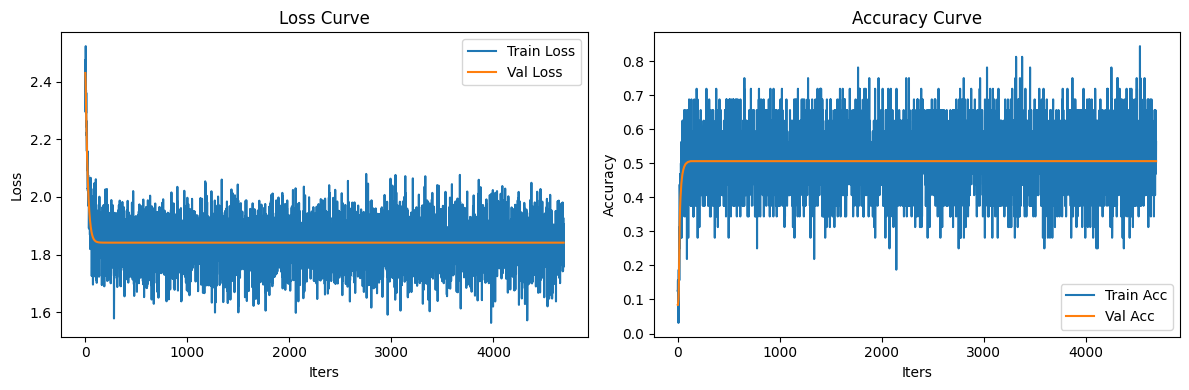

Best train set accuracy: 0.84375
Best validation set accuracy: 0.5062


In [22]:
trainer_8 = train_model(lr = 0.1)
print("Best train set accuracy:", max(trainer_8.train_scores))
print("Best validation set accuracy:", trainer_8.best_score)

[Iter 200]
[Train] loss: 2.30876, score: 0.09375
[Dev] loss: 2.28826, score: 0.11660
[Iter 400]
[Train] loss: 2.29885, score: 0.09375
[Dev] loss: 2.28826, score: 0.11660
[Iter 600]
[Train] loss: 2.26619, score: 0.00000
[Dev] loss: 2.28826, score: 0.11660
[Iter 800]
[Train] loss: 2.26122, score: 0.12500
[Dev] loss: 2.28826, score: 0.11660
[Iter 1000]
[Train] loss: 2.21829, score: 0.15625
[Dev] loss: 2.28826, score: 0.11660
[Iter 1200]
[Train] loss: 2.26222, score: 0.25000
[Dev] loss: 2.28826, score: 0.11660
[Iter 1400]
[Train] loss: 2.25417, score: 0.09375
[Dev] loss: 2.28826, score: 0.11660
best accuracy updated: 0.00000 --> 0.11660
[Iter 1600]
[Train] loss: 2.22088, score: 0.25000
[Dev] loss: 2.28826, score: 0.11660
[Iter 1800]
[Train] loss: 2.36676, score: 0.09375
[Dev] loss: 2.28826, score: 0.11660
[Iter 2000]
[Train] loss: 2.30087, score: 0.09375
[Dev] loss: 2.28826, score: 0.11660
[Iter 2200]
[Train] loss: 2.36232, score: 0.03125
[Dev] loss: 2.28826, score: 0.11660
[Iter 2400]
[Tr

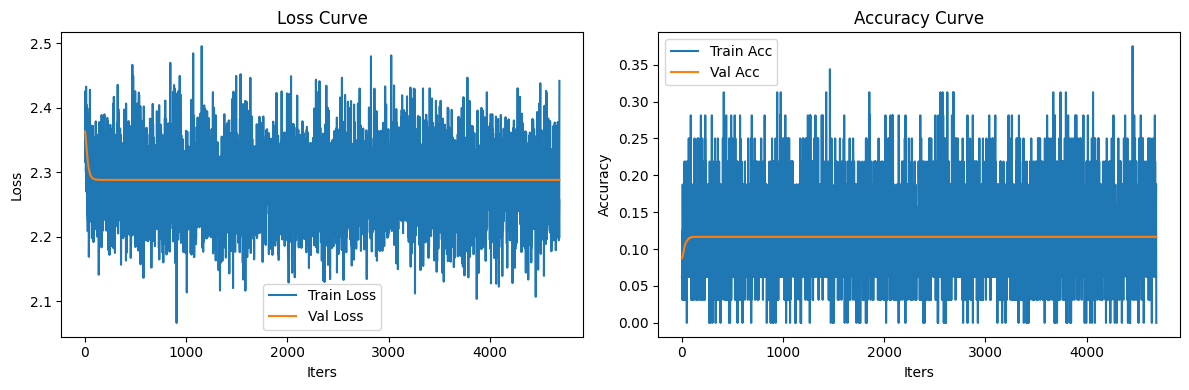

Best train set accuracy: 0.375
Best validation set accuracy: 0.1166


In [23]:
trainer_9 = train_model(lr = 0.01)
print("Best train set accuracy:", max(trainer_9.train_scores))
print("Best validation set accuracy:", trainer_9.best_score)

[Iter 200]
[Train] loss: 2.45297, score: 0.06250
[Dev] loss: 2.38464, score: 0.09560
[Iter 400]
[Train] loss: 2.41082, score: 0.09375
[Dev] loss: 2.38464, score: 0.09560
[Iter 600]
[Train] loss: 2.31504, score: 0.15625
[Dev] loss: 2.38464, score: 0.09560
[Iter 800]
[Train] loss: 2.38710, score: 0.09375
[Dev] loss: 2.38464, score: 0.09560
[Iter 1000]
[Train] loss: 2.35185, score: 0.18750
[Dev] loss: 2.38464, score: 0.09560
[Iter 1200]
[Train] loss: 2.43082, score: 0.06250
[Dev] loss: 2.38464, score: 0.09560
[Iter 1400]
[Train] loss: 2.34606, score: 0.09375
[Dev] loss: 2.38464, score: 0.09560
best accuracy updated: 0.00000 --> 0.09560
[Iter 1600]
[Train] loss: 2.30820, score: 0.03125
[Dev] loss: 2.38464, score: 0.09560
[Iter 1800]
[Train] loss: 2.31238, score: 0.12500
[Dev] loss: 2.38464, score: 0.09560
[Iter 2000]
[Train] loss: 2.35305, score: 0.06250
[Dev] loss: 2.38464, score: 0.09560
[Iter 2200]
[Train] loss: 2.43218, score: 0.06250
[Dev] loss: 2.38464, score: 0.09560
[Iter 2400]
[Tr

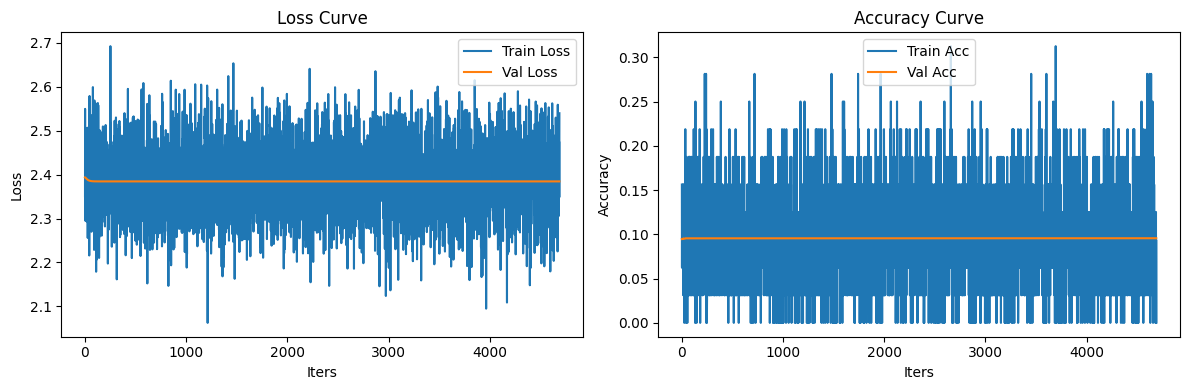

Best train set accuracy: 0.3125
Best validation set accuracy: 0.0956


In [24]:
trainer_9_5 = train_model(lr = 0.001)
print("Best train set accuracy:", max(trainer_9_5.train_scores))
print("Best validation set accuracy:", trainer_9_5.best_score)

### Contrast


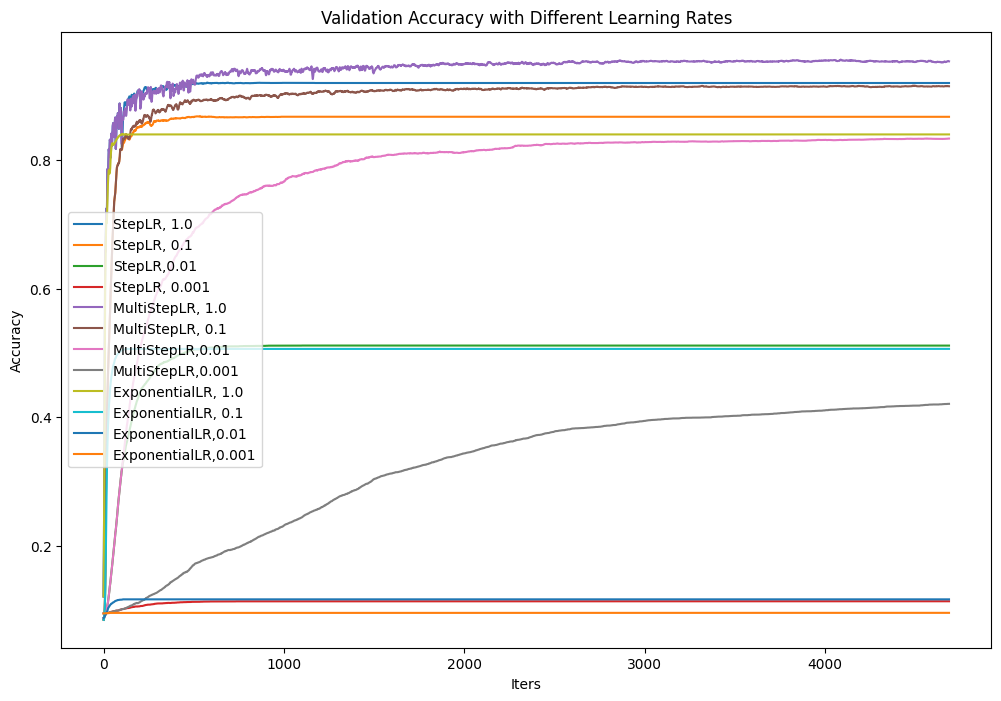

In [26]:
plt.figure(figsize=(12, 8))

plt.plot(trainer_1.dev_scores, label='StepLR, 1.0')
plt.plot(trainer_2.dev_scores, label='StepLR, 0.1')
plt.plot(trainer_3.dev_scores, label='StepLR,0.01')
plt.plot(trainer_3_5.dev_scores, label='StepLR, 0.001')

plt.plot(trainer_4.dev_scores, label='MultiStepLR, 1.0')
plt.plot(trainer_5.dev_scores, label='MultiStepLR, 0.1')
plt.plot(trainer_6.dev_scores, label='MultiStepLR,0.01')
plt.plot(trainer_6_5.dev_scores, label='MultiStepLR,0.001')

plt.plot(trainer_7.dev_scores, label='ExponentialLR, 1.0')
plt.plot(trainer_8.dev_scores, label='ExponentialLR, 0.1')
plt.plot(trainer_9.dev_scores, label='ExponentialLR,0.01')
plt.plot(trainer_9_5.dev_scores, label='ExponentialLR,0.001')

plt.title('Validation Accuracy with Different Learning Rates')
plt.xlabel('Iters')
plt.ylabel('Accuracy')
plt.legend()

#### Use Adam With MultiStepLR

In [1]:
import mynn
from draw_tools.plot import plot
import numpy as np
from struct import unpack
import pickle
import gzip
import matplotlib.pyplot as plt

# fixed seed for experiment
np.random.seed(309)

train_images_path = r'.\dataset\MNIST\train-images-idx3-ubyte.gz'
train_labels_path = r'.\dataset\MNIST\train-labels-idx1-ubyte.gz'

with gzip.open(train_images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        train_imgs=np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(train_labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        train_labs = np.frombuffer(f.read(), dtype=np.uint8)


# choose 10000 samples from train set as validation set.
idx = np.random.permutation(np.arange(num))
# save the index.
with open('idx.pickle', 'wb') as f:
        pickle.dump(idx, f)
train_imgs = train_imgs[idx]
train_labs = train_labs[idx]
valid_imgs = train_imgs[:10000]
valid_labs = train_labs[:10000]
train_imgs = train_imgs[10000:]
train_labs = train_labs[10000:]

# normalize from [0, 255] to [0, 1]
train_imgs = train_imgs / train_imgs.max()
valid_imgs = valid_imgs / valid_imgs.max()



In [2]:
def train_model(nHidden = [128], lr=0.06, epochs=3,early_stop=3, initialize_method='He'):
    # 模型结构：输入层 + 隐藏层 + 输出层
    size_list = [train_imgs.shape[1]] + nHidden + [10]
    lambda_list = [1e-4] * (len(nHidden) + 1)  # 每层一个lambda
    
    # 初始化组件
    model = mynn.models.Model_MLP(size_list, 'ReLU', lambda_list, dropout_p=None, initialize_method=initialize_method)
    my_optimizer = mynn.optimizer.Adam(init_lr=lr, model=model, beta1=0.9, beta2=0.999, epsilon=1e-8)

    scheduler = mynn.lr_scheduler.MultiStepLR(my_optimizer, milestones=[500, 1500, 2500, 3000], gamma=0.5)
    loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    
    
    # 训练运行器
    trainer = mynn.runner.RunnerM(
        model=model,
        optimizer=my_optimizer,
        metric=mynn.metric.accuracy,
        loss_fn=loss_fn,
        batch_size=32,
        scheduler=scheduler
    )
    
    # 执行训练
    trainer.train(
        train_set=[train_imgs, train_labs],
        dev_set=[valid_imgs, valid_labs],
        num_epochs=epochs,
        log_iters=200,
        early_stop = early_stop,
        save_dir = f'./saved_models/Q2/{lr}_MultiStepLR_adam'
    )
    
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 绘制训练和验证损失曲线
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Iters')  # x轴标签
    axes[0].set_ylabel('Loss')    # y轴标签
    axes[0].legend()

    # 绘制训练和验证准确度曲线
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Iters')  # x轴标签
    axes[1].set_ylabel('Accuracy')  # y轴标签
    axes[1].legend()

    plt.tight_layout()  # 自动调整布局
    plt.show()
    
    return trainer

[Iter 200]
[Train] loss: 2.39558, score: 0.03125
[Dev] loss: 2.31265, score: 0.13920
[Iter 400]
[Train] loss: 2.29584, score: 0.09375
[Dev] loss: 2.36949, score: 0.09720
[Iter 600]
[Train] loss: 2.33558, score: 0.12500
[Dev] loss: 2.34664, score: 0.10080
[Iter 800]
[Train] loss: 2.24709, score: 0.09375
[Dev] loss: 2.35073, score: 0.11720
[Iter 1000]
[Train] loss: 2.29109, score: 0.09375
[Dev] loss: 2.33219, score: 0.10030
[Iter 1200]
[Train] loss: 2.29359, score: 0.03125
[Dev] loss: 2.34598, score: 0.09720
[Iter 1400]
[Train] loss: 2.31121, score: 0.03125
[Dev] loss: 2.37664, score: 0.09650
best accuracy updated: 0.00000 --> 0.09490
[Iter 1600]
[Train] loss: 2.27187, score: 0.18750
[Dev] loss: 2.34035, score: 0.10030
[Iter 1800]
[Train] loss: 2.24601, score: 0.18750
[Dev] loss: 2.32420, score: 0.09650
[Iter 2000]
[Train] loss: 2.31057, score: 0.09375
[Dev] loss: 2.32196, score: 0.09490
[Iter 2200]
[Train] loss: 2.34763, score: 0.12500
[Dev] loss: 2.33313, score: 0.09370
[Iter 2400]
[Tr

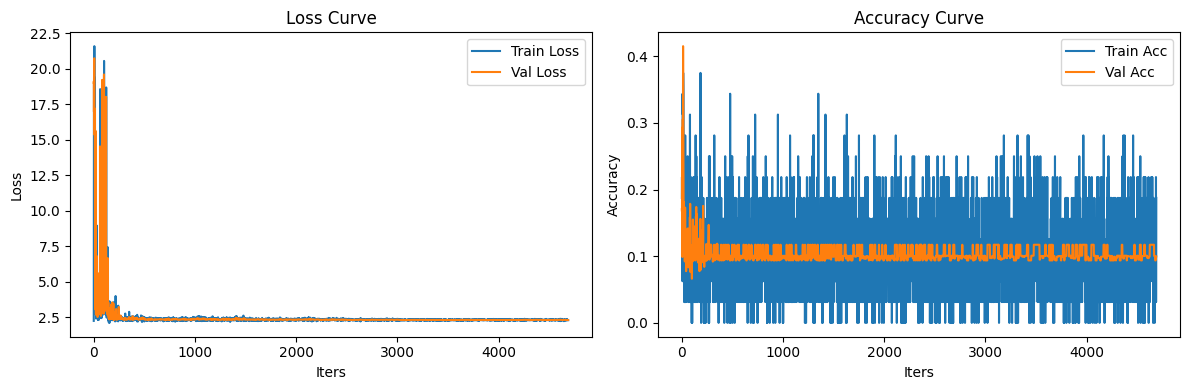

Best train set accuracy: 0.375
Best validation set accuracy: 0.1172


In [3]:
trainer_adam = train_model(lr = 1)
print("Best train set accuracy:", max(trainer_adam.train_scores))
print("Best validation set accuracy:", trainer_adam.best_score)

#### Use Moment SGD With MultiStepLR

In [4]:
def train_model(nHidden = [128], lr=0.06, epochs=3,early_stop=3, initialize_method='He'):
    # 模型结构：输入层 + 隐藏层 + 输出层
    size_list = [train_imgs.shape[1]] + nHidden + [10]
    lambda_list = [1e-4] * (len(nHidden) + 1)  # 每层一个lambda
    
    # 初始化组件
    model = mynn.models.Model_MLP(size_list, 'ReLU', lambda_list, dropout_p=None, initialize_method=initialize_method)
    my_optimizer = mynn.optimizer.MomentGD(init_lr=lr, model=model, mu=0.9)

    scheduler = mynn.lr_scheduler.MultiStepLR(my_optimizer, milestones=[500, 1500, 2500, 3000], gamma=0.5)
    loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    
    
    # 训练运行器
    trainer = mynn.runner.RunnerM(
        model=model,
        optimizer=my_optimizer,
        metric=mynn.metric.accuracy,
        loss_fn=loss_fn,
        batch_size=32,
        scheduler=scheduler
    )
    
    # 执行训练
    trainer.train(
        train_set=[train_imgs, train_labs],
        dev_set=[valid_imgs, valid_labs],
        num_epochs=epochs,
        log_iters=200,
        early_stop = early_stop,
        save_dir = f'./saved_models/Q2/{lr}_MultiStepLR_momentumsgd'
    )
    
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 绘制训练和验证损失曲线
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Iters')  # x轴标签
    axes[0].set_ylabel('Loss')    # y轴标签
    axes[0].legend()

    # 绘制训练和验证准确度曲线
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Iters')  # x轴标签
    axes[1].set_ylabel('Accuracy')  # y轴标签
    axes[1].legend()

    plt.tight_layout()  # 自动调整布局
    plt.show()
    
    return trainer

[Iter 200]
[Train] loss: 0.55777, score: 0.81250
[Dev] loss: 0.38396, score: 0.88110
[Iter 400]
[Train] loss: 0.24763, score: 0.93750
[Dev] loss: 0.35730, score: 0.89070
[Iter 600]
[Train] loss: 0.66209, score: 0.81250
[Dev] loss: 0.23092, score: 0.93400
[Iter 800]
[Train] loss: 0.25218, score: 0.93750
[Dev] loss: 0.22145, score: 0.93830
[Iter 1000]
[Train] loss: 0.42283, score: 0.90625
[Dev] loss: 0.22030, score: 0.93800
[Iter 1200]
[Train] loss: 0.24252, score: 0.93750
[Dev] loss: 0.20988, score: 0.94340
[Iter 1400]
[Train] loss: 0.13448, score: 0.96875
[Dev] loss: 0.20859, score: 0.94370
best accuracy updated: 0.00000 --> 0.94600
[Iter 1600]
[Train] loss: 0.32117, score: 0.90625
[Dev] loss: 0.19299, score: 0.94900
[Iter 1800]
[Train] loss: 0.17732, score: 0.93750
[Dev] loss: 0.19144, score: 0.94790
[Iter 2000]
[Train] loss: 0.22703, score: 0.90625
[Dev] loss: 0.18782, score: 0.95200
[Iter 2200]
[Train] loss: 0.08817, score: 1.00000
[Dev] loss: 0.18589, score: 0.95090
[Iter 2400]
[Tr

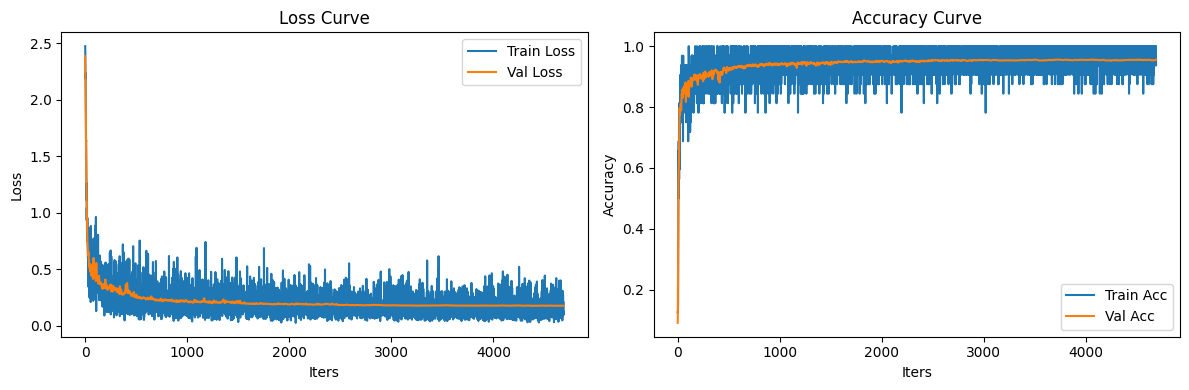

Best train set accuracy: 0.375
Best validation set accuracy: 0.1172


In [5]:
trainer_momsgd = train_model(lr = 1)
print("Best train set accuracy:", max(trainer_adam.train_scores))
print("Best validation set accuracy:", trainer_adam.best_score)